In [2]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.tree import plot_tree

Mounted at /content/drive


## **Data Exploration**

In [3]:
# Path to your CSV file in Google Drive
file_path = '/content/drive/MyDrive/Grad School/CIS 586/Project/Data/engine_data.csv'

# Read the CSV file
engine = pd.read_csv(file_path)
engine.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [4]:
# Expoloratory Data Analysis
engine.info()

engine.isnull().sum()
# no null values present in the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
Engine Condition    0
dtype: int64

In [5]:
engine.dtypes

# all the data types are numeric

Engine rpm            int64
Lub oil pressure    float64
Fuel pressure       float64
Coolant pressure    float64
lub oil temp        float64
Coolant temp        float64
Engine Condition      int64
dtype: object

In [6]:
engine.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433,0.630509
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749,0.482679
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325,0.000000
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421,0.000000
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662,1.000000
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411,1.000000
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912,1.000000


In [7]:
engine['Engine Condition'].value_counts()

Engine Condition
1    12317
0     7218
Name: count, dtype: int64

# Initial Data Ananlysis

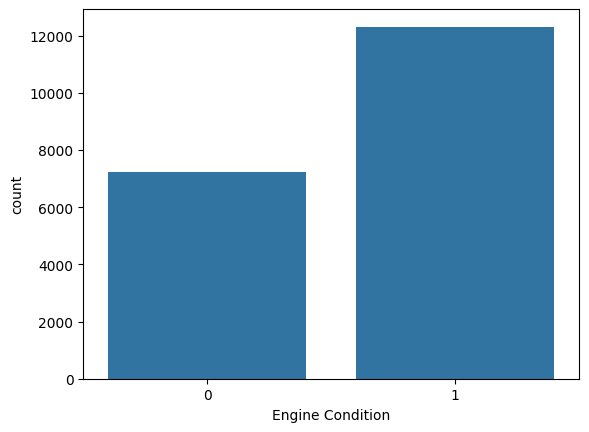

In [8]:
sns.countplot(x=engine['Engine Condition'])
plt.show()

<Axes: ylabel='count'>

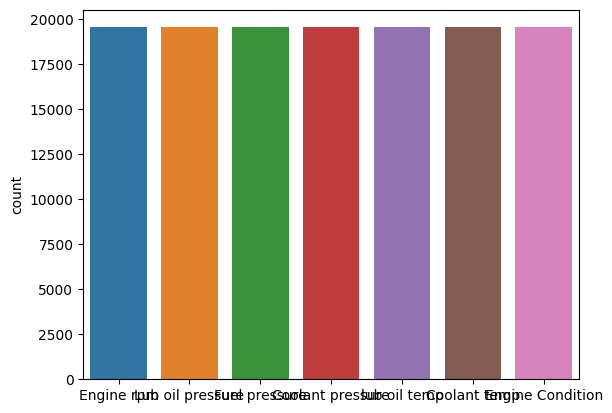

In [10]:
sns.countplot(engine)

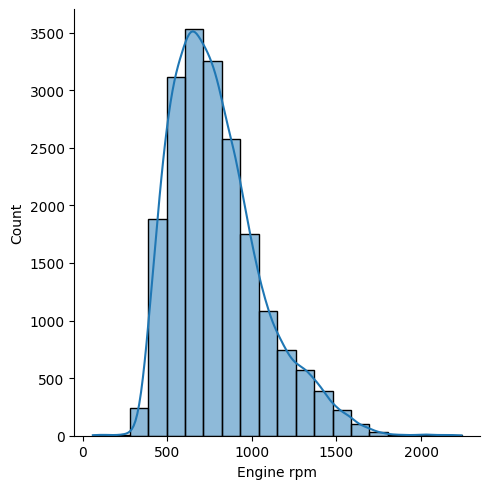

In [11]:
sns.displot(data=engine['Engine rpm'], bins= 20, kde= True)
plt.show()

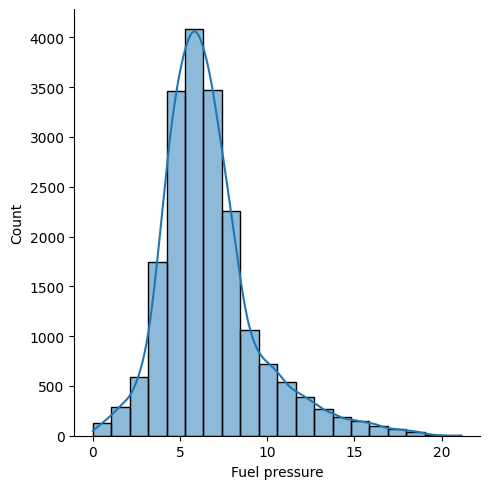

In [12]:
sns.displot(data=engine['Fuel pressure'], bins= 20, kde= True)
plt.show()

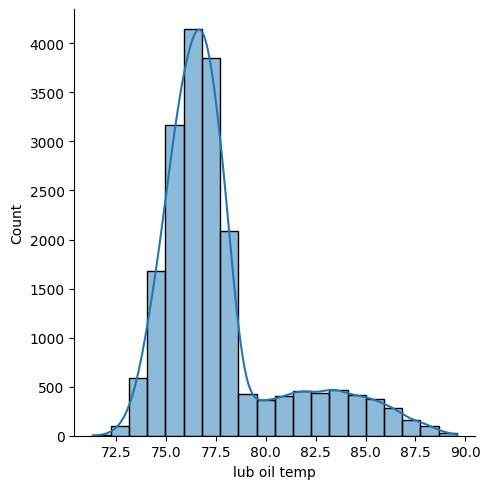

In [13]:
sns.displot(data=engine['lub oil temp'], bins= 20, kde= True)
plt.show()

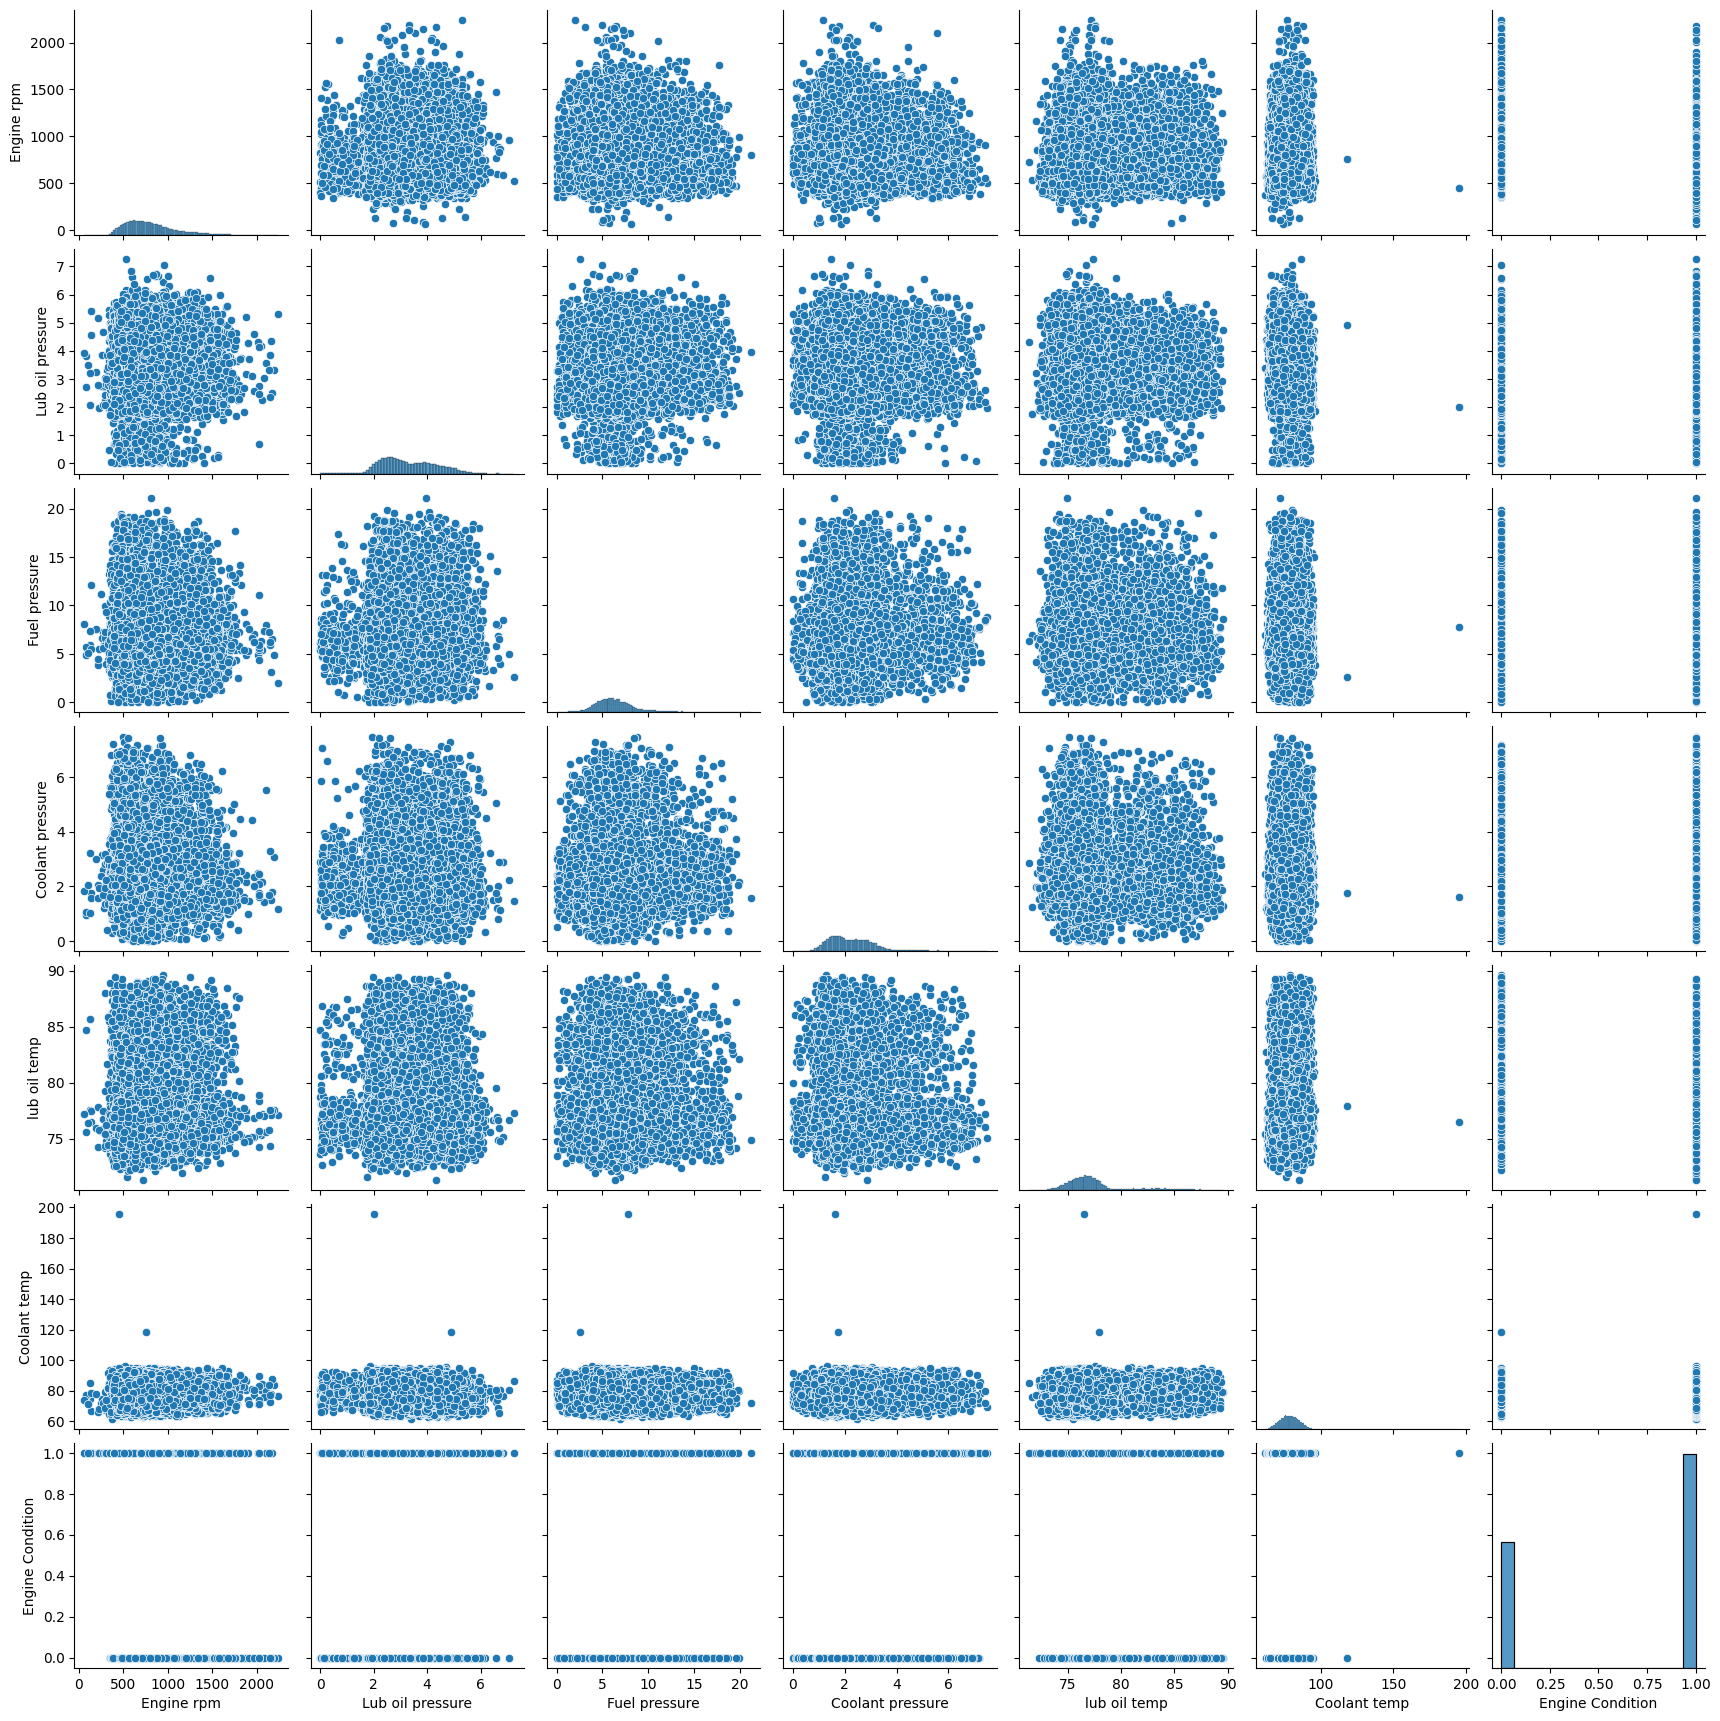

In [14]:
#visualizing the data
sns.pairplot(engine)
plt.show()

<Axes: >

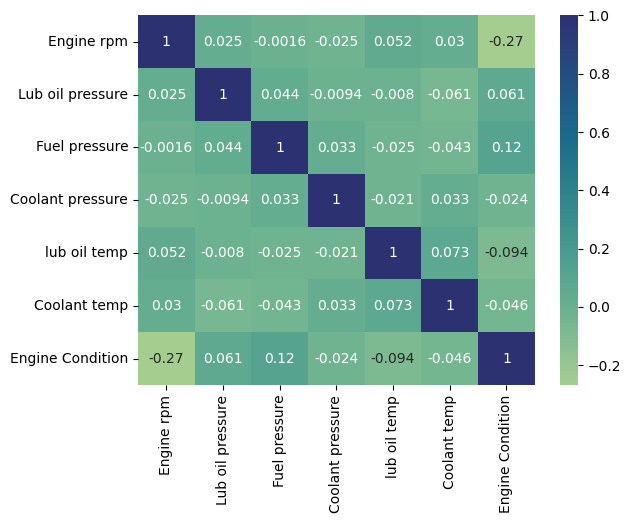

In [15]:
# Checking the correlation between parameters
sns.heatmap(engine.corr(), annot=True, cmap='crest')

# based on the results, I may want to try to create some interaction variables to find some stronger correlations, but I'm not sure which variables.

## **Data Preprocessing**

In [16]:
# Data Preprocessing, normalzing data using Scaler
scaler = MinMaxScaler()

X = engine.drop('Engine Condition', axis=1)
y = engine['Engine Condition']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

# Preprocess the data by scaling using MinMaxScaler and StandardScaler
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)


In [17]:
X_train_minmax

array([[0.31450872, 0.56940397, 0.46451928, 0.34381138, 0.77486242,
        0.12407342],
       [0.27134986, 0.57370861, 0.27819292, 0.393586  , 0.35490909,
        0.23703536],
       [0.23553719, 0.71890384, 0.16223459, 0.15245955, 0.18820496,
        0.14173929],
       ...,
       [0.35445363, 0.40623481, 0.23088891, 0.22102821, 0.25883371,
        0.07776175],
       [0.52708907, 0.3324083 , 0.3557727 , 0.4311572 , 0.31534656,
        0.1455132 ],
       [0.37052342, 0.53051033, 0.26538658, 0.17798048, 0.66564985,
        0.18204922]])

In [18]:
# Initialize and train a Random Forest classifier for feature selection (FS)
rf_FS = RandomForestClassifier(random_state=45)
rf_FS.fit(X_train_minmax, y_train)

RandomForestClassifier(random_state=45)

In [19]:
rf_FS.score(X_test_minmax, y_test)

0.6496032761709751

In [20]:
# Parameters for the grid search to test
grid_param = {
    'n_estimators': [100, 120],
    'criterion': ['gini', 'entropy'],
    'max_depth': range(2, 35, 10),
    'max_features': ['auto', 'log2'],
    'min_samples_leaf': range(10, 50, 10),
    'min_samples_split': range(10, 20, 5)
}

In [21]:
cv = StratifiedKFold(n_splits=5)

In [22]:
# Running the GridSearchCV using stratified Kfolds to assess best tuning of the parameters
grid_search = GridSearchCV(estimator=rf_FS, param_grid=grid_param, cv=cv, n_jobs= -1, verbose= 3)
grid_search.fit(X_train_minmax, y_train)
#took 44 mins to run, may need to reduce some ranges.

Fitting 5 folds for each of 256 candidates, totalling 1280 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(random_state=45), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 35, 10),
                         'max_features': ['auto', 'log2'],
                         'min_samples_leaf': range(10, 50, 10),
                         'min_samples_split': range(10, 20, 5),
                         'n_estimators': [100, 120]},
             verbose=3)

In [23]:
# Assessing the best parameters for th random forest tree to better identify the best features in the given dataset
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 22,
 'max_features': 'auto',
 'min_samples_leaf': 40,
 'min_samples_split': 10,
 'n_estimators': 120}

## **Feature Selection**

In [24]:
# Updating the parameters to optimize the random forest feature selector to identify best parameters
opt_rf_fs = RandomForestClassifier( n_estimators= 120,
                                    criterion='gini',
                                    max_depth= 22,
                                    max_features= 'auto',
                                    min_samples_leaf= 40,
                                    min_samples_split= 10,
                                    random_state= 23
)
opt_rf_fs.fit(X_train_minmax, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomForestClassifier(max_depth=22, max_features='auto', min_samples_leaf=40,
                       min_samples_split=10, n_estimators=120, random_state=23)

In [25]:
# opt_rf_fs.score(X_test_minmax, y_test)
# #accuracy improved 2%!

In [26]:
# Assessing most important features based on optimized RF
feature_importances = opt_rf_fs.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
print(feature_importance_df.head(10))

# using the top two since the importance isn't that strong

            Feature  Importance
0        Engine rpm    0.456715
2     Fuel pressure    0.159025
4      lub oil temp    0.135012
1  Lub oil pressure    0.100137
3  Coolant pressure    0.076245
5      Coolant temp    0.072866


## **Random Forest Classification Analysis**

In [27]:
# filtering the engine dataset to only the top 3 features
engine_opt = engine.iloc[:, [0, 2, 4, 6]]

In [28]:
# Refitting the Random Forest Model to see if there was any improvement with th e new features only
scaler = MinMaxScaler()

X_opt = engine_opt.drop('Engine Condition', axis=1)
y_opt = engine_opt['Engine Condition']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_opt, y_opt, test_size=0.2, random_state=32)

# Preprocess the data by scaling using MinMaxScaler
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)


In [29]:
# Initialize and re-train the Random Forest classifier with updated features selected
rf_clf = RandomForestClassifier(random_state=32)
rf_clf.fit(X_train_minmax, y_train)

RandomForestClassifier(random_state=32)

In [40]:
rf_clf= RandomForestClassifier( n_estimators= 120,
                                criterion='gini',
                                max_depth= 22,
                                max_features= 'auto',
                                min_samples_leaf= 40,
                                min_samples_split= 10,
                                random_state= 35
)
rf_clf.fit(X_train_minmax, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomForestClassifier(max_depth=22, max_features='auto', min_samples_leaf=40,
                       min_samples_split=10, n_estimators=120, random_state=35)

In [41]:
# Checking for accuracy before one more grid search to compare accuracy for best results.
rf_clf.score(X_test_minmax, y_test)

0.6734067059124648

In [42]:
# Reassessing parameters given reduced dataset
grid_param2 = {
    'n_estimators': [100, 120],
    'criterion': ['gini', 'entropy'],
    'max_depth': range(5, 25, 5),
    'max_features': ['auto', 'log2'],
    'min_samples_leaf': range(30, 120, 30),
    'min_samples_split': range(10, 20, 5)
}

In [33]:
# Second GridSearch on optimized dataset to get refined parameters to produce best possible accuracy
cv = StratifiedKFold(n_splits=5)
grid_search = GridSearchCV(estimator=rf_clf, param_grid=grid_param2, cv= cv, scoring='accuracy', n_jobs= -1, verbose= 3)
grid_search.fit(X_train_minmax, y_train)
#26 minutes to run

Fitting 7 folds for each of 192 candidates, totalling 1344 fits


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


GridSearchCV(cv=StratifiedKFold(n_splits=7, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(max_depth=22, max_features='auto',
                                              min_samples_leaf=40,
                                              min_samples_split=10,
                                              n_estimators=120,
                                              random_state=23),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(5, 25, 5),
                         'max_features': ['auto', 'log2'],
                         'min_samples_leaf': range(30, 120, 30),
                         'min_samples_split': range(10, 20, 5),
                         'n_estimators': [100, 120]},
             scoring='accuracy', verbose=3)

In [34]:
# Assessing the best parameters for th random forest tree to better identify the best features in the given dataset
grid_search.best_params_

{'criterion': 'entropy',
 'max_depth': 15,
 'max_features': 'auto',
 'min_samples_leaf': 90,
 'min_samples_split': 10,
 'n_estimators': 120}

In [43]:
# Updating the parameters to optimize the random forest feature selector to identify best parameters
opt_rf_clf= RandomForestClassifier( n_estimators= 120,
                                    criterion='entropy',
                                    max_depth= 15,
                                    max_features= 'auto',
                                    min_samples_leaf= 90,
                                    min_samples_split= 10,
                                    random_state= 25
)
opt_rf_clf.fit(X_train_minmax, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:424: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(


RandomForestClassifier(criterion='entropy', max_depth=15, max_features='auto',
                       min_samples_leaf=90, min_samples_split=10,
                       n_estimators=120, random_state=25)

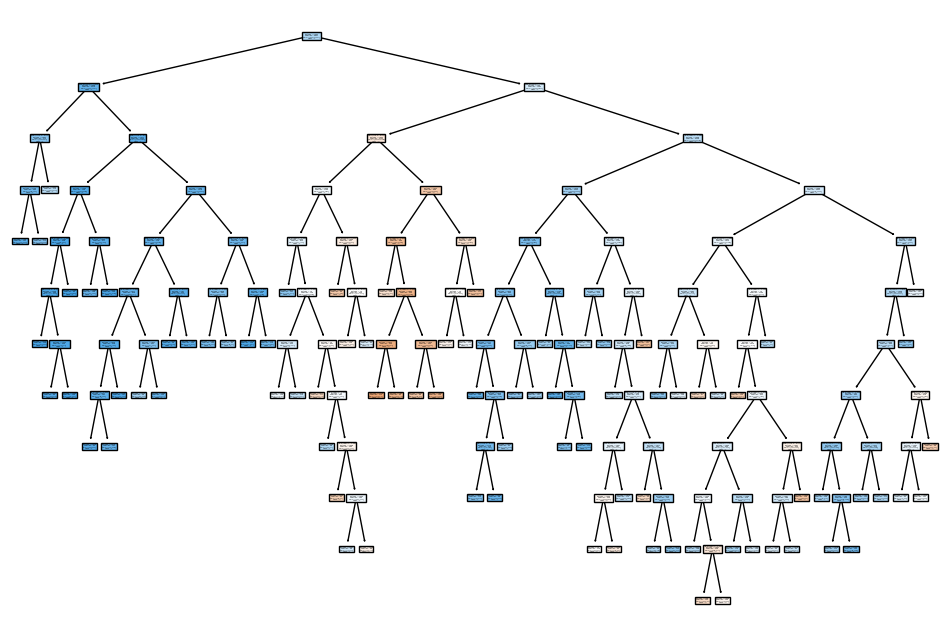

In [44]:
# Get the class names as a list of strings
class_names = [str(cls) for cls in opt_rf_clf.classes_]

# Choose one tree from the random forest to visualize
tree = opt_rf_clf.estimators_[1]

# Plot the single decision tree
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=X_opt.columns, class_names=class_names, filled=True)
plt.show()

In [45]:
opt_rf_clf.score(X_test_minmax, y_test)
# the accuracy slightly increased, thus, I feel comfortable leaving as is or keeping the new parameters.

0.6744305093422063

In [46]:
# Making a predictions on the test set
y_pred = opt_rf_clf.predict(X_test_minmax)
print('Random Forest Classifier Accuracy: ',accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


Random Forest Classifier Accuracy:  0.6744305093422063
              precision    recall  f1-score   support

           0       0.57      0.35      0.43      1386
           1       0.70      0.85      0.77      2521

    accuracy                           0.67      3907
   macro avg       0.64      0.60      0.60      3907
weighted avg       0.66      0.67      0.65      3907



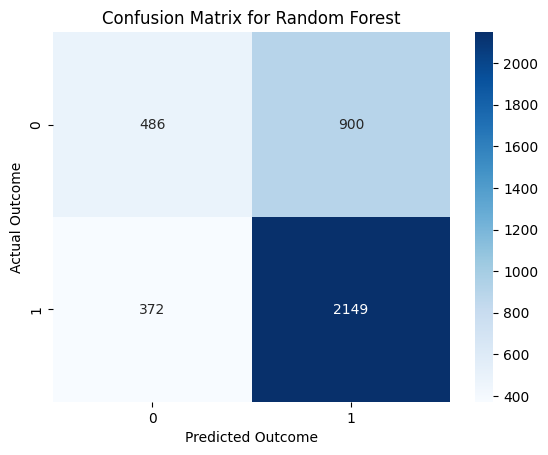

In [47]:
# confusion matrix for random forest classifier
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.title('Confusion Matrix for Random Forest')
plt.show()

## **Gradient Boost Analysis**

In [48]:
# filtering the engine dataset to only the top 3 features
engine_gb = engine.iloc[:, [0, 2, 4, 6]]
# Refitting the Random Forest Model to see if there was any improvement with th e new features only
scaler = MinMaxScaler()

X_gb = engine_gb.drop('Engine Condition', axis=1)
y_gb = engine_gb['Engine Condition']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_gb, y_gb, test_size=0.2, stratify=y_gb, random_state=15)

# Preprocess the data by scaling using MinMaxScaler
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)

In [49]:
# Initializing the Gradient boost
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train_minmax, y_train)

GradientBoostingClassifier()

In [50]:
# Checking initial accuracy
gb_clf.score(X_test_minmax, y_test)
# Slight decrease from the random forest classifier.

0.6570258510366009

In [51]:
gb_grid_param = {
    'n_estimators': [80, 100, 120],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': range(3, 10, 2)
}

In [52]:
cv = StratifiedKFold(n_splits=7)
gb_grid_search = GridSearchCV(gb_clf, param_grid=gb_grid_param, cv=cv, scoring='accuracy', n_jobs= -1, verbose= 3)

In [53]:
#score check, about the same, slightly lower than rf.
gb_grid_search.fit(X_test_minmax, y_test)
# see best hyperparsmetrs
gb_grid_search.best_params_

Fitting 7 folds for each of 36 candidates, totalling 252 fits


{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [54]:
# check for accuracy improvement
opt1_gb_clf= GradientBoostingClassifier( n_estimators= 100,
                                    learning_rate= 0.05,
                                    max_depth= 3
)
opt1_gb_clf.fit(X_train_minmax, y_train)

GradientBoostingClassifier(learning_rate=0.05)

In [55]:
# Making a predictions on the test set
y_pred = opt1_gb_clf.predict(X_test_minmax)
print('Gradient Boost Classifier Accuracy: ',accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Gradient Boost Classifier Accuracy:  0.6626567699001792
              precision    recall  f1-score   support

           0       0.57      0.34      0.42      1444
           1       0.69      0.85      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.59      3907
weighted avg       0.65      0.66      0.64      3907



In [56]:
# Checking to see if I can improve the accuracy above 67% by reassessing the parameters a bit more.
gb_grid_param2 = {
    'n_estimators': [100, 105, 110],
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [2, 3, 4]
}

In [57]:
cv = StratifiedKFold(n_splits=10)
gb_grid_search = GridSearchCV(gb_clf, param_grid=gb_grid_param2, cv=cv, scoring='accuracy', n_jobs= -1, verbose= 3)

In [58]:
gb_grid_search.fit(X_train_minmax, y_train)
# see best hyperparsmetrs
print(gb_grid_search.best_params_)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 110}


In [59]:
# check for accuracy improvement
opt2_gb_clf= GradientBoostingClassifier( n_estimators= 110,
                                    learning_rate= 0.05,
                                    max_depth= 2
)
opt2_gb_clf.fit(X_train_minmax, y_train)

GradientBoostingClassifier(learning_rate=0.05, max_depth=2, n_estimators=110)

In [60]:
# Making a predictions on the test set
y_pred = opt2_gb_clf.predict(X_test_minmax)
print('Gradient Boost Classifier Accuracy: ',accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

# no change in the overall accuracy, but still getting 67% as the highest which is a 1% increase from the previous geneeral hyperparameters.
# data is skewed, there is more 1's than 0's.

Gradient Boost Classifier Accuracy:  0.6641924750447914
              precision    recall  f1-score   support

           0       0.58      0.33      0.42      1444
           1       0.69      0.86      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.59      0.59      3907
weighted avg       0.65      0.66      0.64      3907



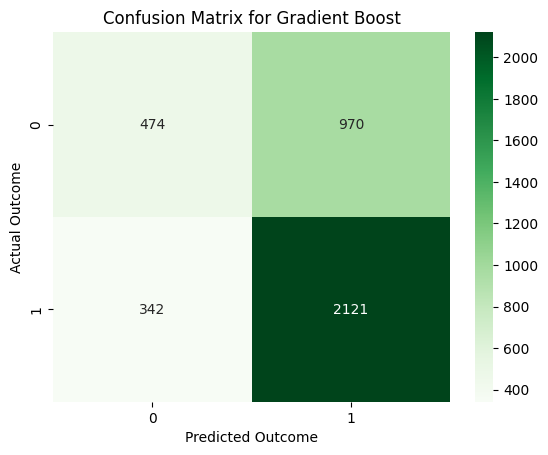

In [61]:
# confusion matrix for gradient boost classifier
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.title('Confusion Matrix for Gradient Boost')
plt.show()

## **Support Vector Machine (SVM) Analysis**

In [62]:
# filtering the engine dataset to only the top 3 features
engine_sv = engine.iloc[:, [0, 2, 4, 6]]
# Refitting the Random Forest Model to see if there was any improvement with th e new features only
scaler = MinMaxScaler()

X_sv = engine_sv.drop('Engine Condition', axis=1)
y_sv = engine_sv['Engine Condition']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_sv, y_sv, test_size=0.2,stratify=y_sv, random_state=1)

# Preprocess the data by scaling using MinMaxScaler
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)



In [63]:
# Initializing the support vector machine classifier
svm_clf = SVC()
svm_clf.fit(X_train_minmax, y_train)

SVC()

In [64]:
# Running SVM on generalized parameters
sv_clf= SVC(C= 0.1,
            kernel= 'poly',
            gamma= 'auto'
)
sv_clf.fit(X_train_minmax, y_train)

SVC(C=0.1, gamma='auto', kernel='poly')

In [65]:
# accuracy check, initial
sv_clf.score(X_test_minmax, y_test)

0.6304069618633222

In [66]:
svm_grid_param= {
    'C': [0.01, 0.05, 0.1, np.inf],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [67]:
# Using GridSearchCv to tune the hyperparamertes.
cv = StratifiedKFold(n_splits=5)
grid_search= GridSearchCV(svm_clf, param_grid= svm_grid_param, cv=cv, scoring= 'accuracy',  n_jobs= -1, verbose= 3)

In [68]:
grid_search.fit(X_train_minmax, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py", line 180, in fit
    self._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 600, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils/_param

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.05, 0.1, inf],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['rbf', 'poly']},
             scoring='accuracy', verbose=3)

In [69]:
grid_search.best_params_

{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

In [70]:
# Generating an optimized model, given GridSearchCV outputs
opt_svm_clf= SVC(C= 0.1,
                 kernel= 'rbf',
                 gamma= 'scale'
)
opt_svm_clf.fit(X_train_minmax, y_train)

SVC(C=0.1)

In [71]:
# Prediciting a y to test accuracy for comparison
y_pred= opt_svm_clf.predict(X_test_minmax)

# accuracy and classification report
print('Support Vector Machine Classifier Accuracy: ',accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# the accuracy increasedby 2%, however, it did not reach the highest accuracy achieved of 67%.

Support Vector Machine Classifier Accuracy:  0.6575377527514717
              precision    recall  f1-score   support

           0       0.58      0.26      0.36      1444
           1       0.67      0.89      0.77      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.57      0.56      3907
weighted avg       0.64      0.66      0.61      3907



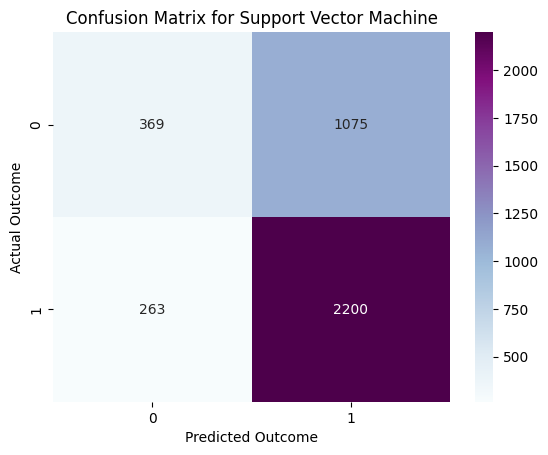

In [72]:
# confusion matrix for Support Vector classifier
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='BuPu')
plt.xlabel('Predicted Outcome')
plt.ylabel('Actual Outcome')
plt.title('Confusion Matrix for Support Vector Machine')
plt.show()